# Auto-immune dataset - Milo differential abundance analysis example

Example workflows for more details:

- [Milopy vignette](https://nbviewer.org/github/emdann/milopy/blob/master/notebooks/milopy_example.ipynb)
- [Extended milo example](https://github.com/Teichlab/scripts/blob/main/conditions/extended_milopy_example.ipynb)

In [1]:
import os,sys
import numpy as np
import pandas as pd
import scanpy as sc


In [2]:
import sys
sys.path.append('/home/jovyan/notebooks_bidossessi/Inflammatory/Remapped/autoimmuneSC/AIID_notebooks/')

from inflapy.immunoFunc import *

In [3]:
print(sc.__version__)

1.9.1


In [4]:
import milopy.core as milo
import milopy

import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
import warnings
warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
import seaborn as sns
import random
import sc_toolbox

import rpy2.rinterface_lib.callbacks
import anndata2ri
import logging

from rpy2.robjects import pandas2ri
from rpy2.robjects import r

sc.settings.verbosity = 0
rpy2.rinterface_lib.callbacks.logger.setLevel(logging.ERROR)

pandas2ri.activate()
anndata2ri.activate()

%load_ext rpy2.ipython

### Load integrated dataset

In [60]:
dir_save="/nfs/team205/bh14/Datasets/Remapped/raw_adata/SCVI_Results/All_Tissue_or_Nonimmune/Subset/"

In [61]:
adata = sc.read_h5ad(dir_save+"scANVI_Myeloid_cells_out/Myeloid_cell_from_Tissue_scANVI.h5ad")

In [9]:
marker_genes = ['CD74', 'HLA-DRA', 'CLEC9A', 'DNASE1L3', 'IDO1', 'XCR1', 'FCER1A', 'S100A9',
               'CLEC10A', 'CD1C', 'PKIB', 'FSCN1',  'LAMP3', 'CCR7', 'CD14', 'FCGR3A', 'C1QA', 
                'CRISPLD2', 'CLU', 'CDKN1C', 'ZNF703', 'CX3CR1', 'GPNMB', 'TREM2', 'BHLHE41', 
                'TNIP3', 'CCL2', 'SLC40A1', 'VCAM1', 'CD209', 'SDS', 'IGF1', 'MKI67', 'TOP2A', 
                'CD3E', 'CD8A', 'ITGAM', 'SIRPA']

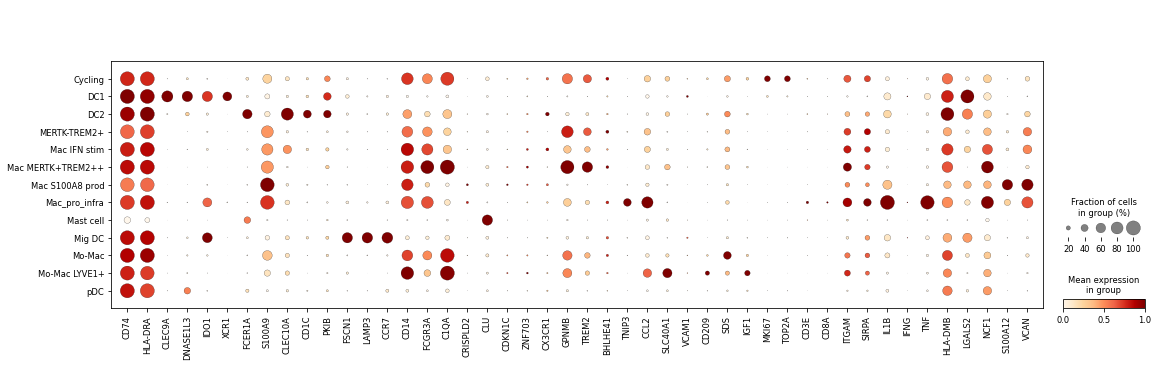

In [9]:
sc.pl.dotplot(adata, marker_genes + ['IL1B', 'IFNG', 'TNF', 'HLA-DMB', 'LGALS2', 'NCF1', 'S100A12', 'VCAN'],
              groupby='Cell_type_scANVI', standard_scale='var',
              cmap='OrRd', swap_axes=False)

In [10]:
adata.obs.Cell_type_scANVI.value_counts(dropna=False)

Mac MERTK+TREM2++    10400
DC2                   8737
Mo-Mac LYVE1+         7174
Mo-Mac                5903
Mac IFN stim          3941
Mac S100A8 prod       3356
MERTK-TREM2+          3288
Mac_pro_infra         2275
DC1                   1688
Cycling               1670
Mig DC                1280
Mast cell             1121
pDC                    610
Name: Cell_type_scANVI, dtype: int64

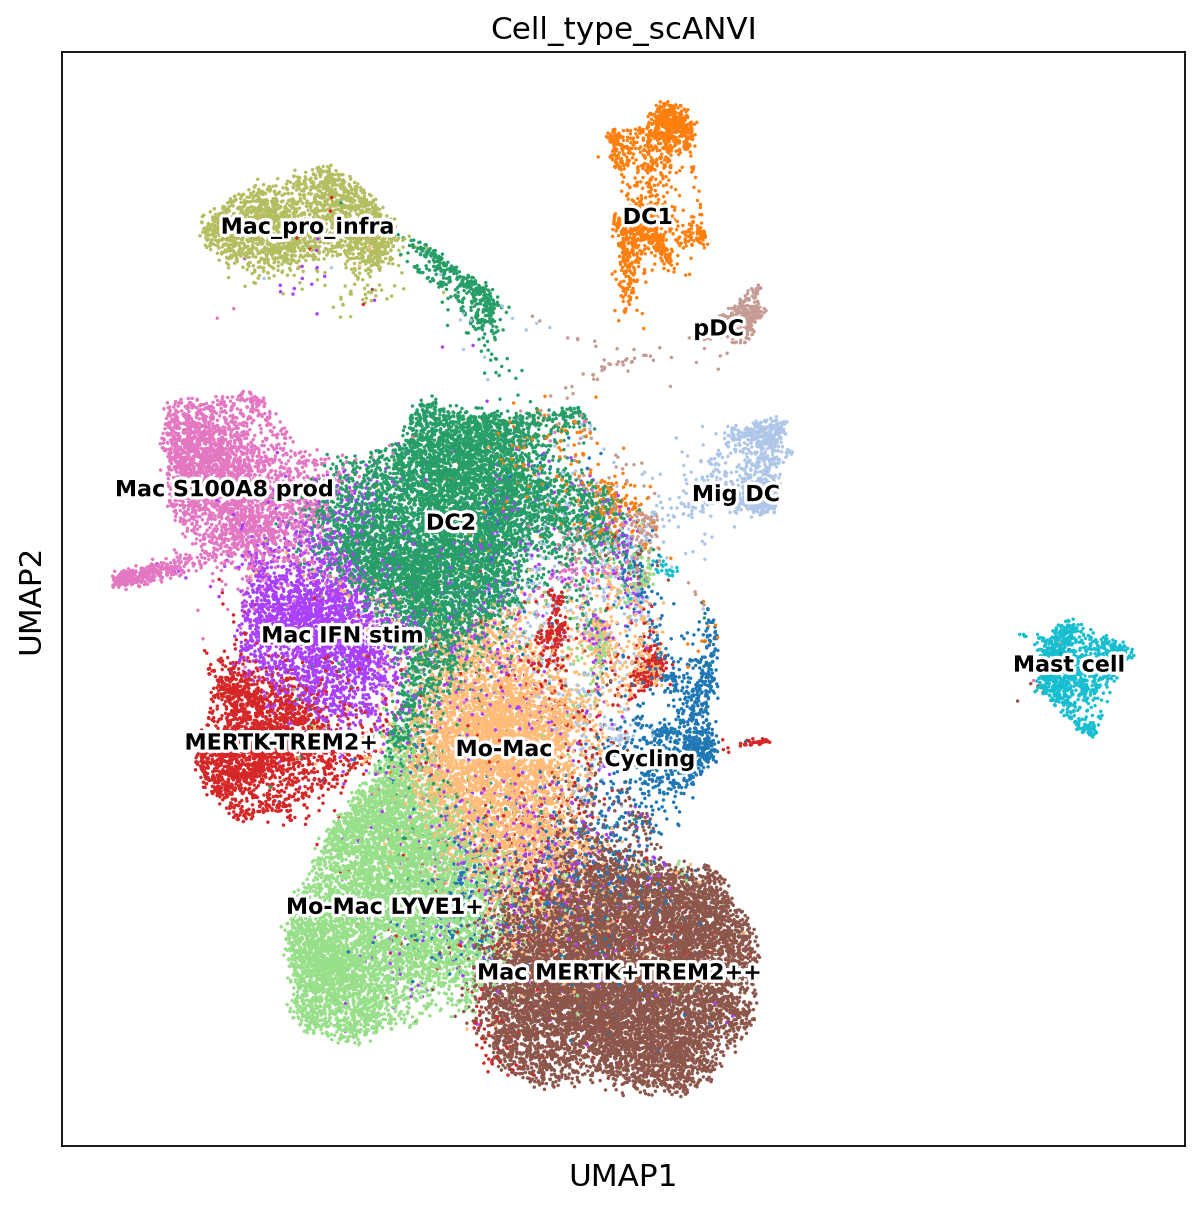

In [11]:
sc.set_figure_params(figsize=(9,9))
sc.pl.umap(
    adata,
    color=["Cell_type_scANVI"],
    ncols=2,
    frameon=True,
    size=10,
    legend_fontoutline=3,
    legend_fontsize=10,
    legend_loc="on data",
    cmap='OrRd'

)

We will keep only donors with average 10 cells in each cluster

In [13]:
adata.shape

(51443, 18033)

In [14]:
ncel = len(adata.obs.Cell_type_scANVI.unique())

In [15]:
size_by_donor = adata.obs.groupby(["donor_id"]).size()

In [16]:
donors_to_keep = [
    donor
    for donor in size_by_donor.index
    if size_by_donor[donor] >= 10*ncel
]

In [17]:
len(donors_to_keep)

56

In [18]:
len(adata.obs.donor_id.unique())

108

In [19]:
donors_to_keep

['5028STDY7152012',
 '5028STDY7152013',
 '5028STDY7152016',
 '5028STDY7152017',
 'BX254_ST_ERS5040444',
 'GSM3972009',
 'GSM3972013',
 'GSM3972016',
 'GSM3972017',
 'GSM3972019',
 'GSM3972020',
 'GSM3972022',
 'GSM3972024',
 'GSM3972025',
 'GSM3972026',
 'GSM3972028',
 'GSM3972030',
 'HB1_GSM3433578',
 'HB3-1_GSM3433580',
 'HB3-2_GSM3433581',
 'HC0547_ERS3741151',
 'HC0572_ERS3741152',
 'HC0701_ERS3741153',
 'HC0732_ERS3741154',
 'HT28Thyroid',
 'HT29Thyroid',
 'Patient_23_Colon_GSM4977002',
 'PsA-3830_GSM4908803',
 'PsA-3849_GSM4908804',
 'PsA-22228_GSM4908802',
 'SA131_ERS3741157',
 'SA132_ERS3741164',
 'SA138_ERS3741158',
 'SA139_ERS3741159',
 'SA144_ERS3741168',
 'SA145_ERS3741169',
 'SA146_ERS3741155',
 'SA149P_ERS3741175',
 'SA149_ERS3741174',
 'SA151_ERS3741170',
 'SA153_ERS3741177',
 'SA154_ERS3741176',
 'SA159_ERS3741165',
 'SA160_ERS3741161',
 'SA161_ERS3741162',
 'SA166_ERS3741171',
 'SA168_ERS3741166',
 'SA172_ERS3741156',
 'SA174_ERS3741163',
 'SA220_ERS3741160',
 'SA222_E

In [20]:
adata = adata[adata.obs["donor_id"].isin(donors_to_keep)]

In [21]:
adata.shape

(48957, 18033)

In [22]:
adata.obs.disease.value_counts()

Rheumatoid Arthritis          24186
Undifferentiated Arthritis     6400
Healthy                        5189
Crohn's Disease                3932
Oligoarticular JIA             3732
Hashimoto’s thyroiditis        1966
Psoriatic arthritis            1698
Paediatric IBD                 1310
Uninflamed CD                   544
Name: disease, dtype: int64

In [23]:
#We removed Uninflamed CD because it size very different(small)
adata = adata[adata.obs.disease!="Uninflamed CD"].copy()

In [24]:
sample_cols = ['dataset_id', 'donor_id', 'tissue', 'disease', 'cell_source', 'Cell_type_scANVI']
sample_df = adata.obs[sample_cols].groupby(sample_cols).size().reset_index()
sample_df.columns = sample_cols + ['n_cells']
sample_df = sample_df[sample_df['n_cells'] > 0].copy()
sample_df

,dataset_id,donor_id,tissue,disease,cell_source,Cell_type_scANVI,n_cells
125099,E-MTAB-8322_Stefeno_2020,HC0547_ERS3741151,synovial membrane,Healthy,macrophage,Cycling,25
125101,E-MTAB-8322_Stefeno_2020,HC0547_ERS3741151,synovial membrane,Healthy,macrophage,DC2,86
125102,E-MTAB-8322_Stefeno_2020,HC0547_ERS3741151,synovial membrane,Healthy,macrophage,MERTK-TREM2+,2
125104,E-MTAB-8322_Stefeno_2020,HC0547_ERS3741151,synovial membrane,Healthy,macrophage,Mac MERTK+TREM2++,365
125105,E-MTAB-8322_Stefeno_2020,HC0547_ERS3741151,synovial membrane,Healthy,macrophage,Mac S100A8 prod,8
...,...,...,...,...,...,...,...
3031998,Qian_Yue_Zhang_2022,HT29Thyroid,Thyroid,Hashimoto’s thyroiditis,Thyroid,Mast cell,1
3031999,Qian_Yue_Zhang_2022,HT29Thyroid,Thyroid,Hashimoto’s thyroiditis,Thyroid,Mig DC,51
3032000,Qian_Yue_Zhang_2022,HT29Thyroid,Thyroid,Hashimoto’s thyroiditis,Thyroid,Mo-Mac,127
3032001,Qian_Yue_Zhang_2022,HT29Thyroid,Thyroid,Hashimoto’s thyroiditis,Thyroid,Mo-Mac LYVE1+,10


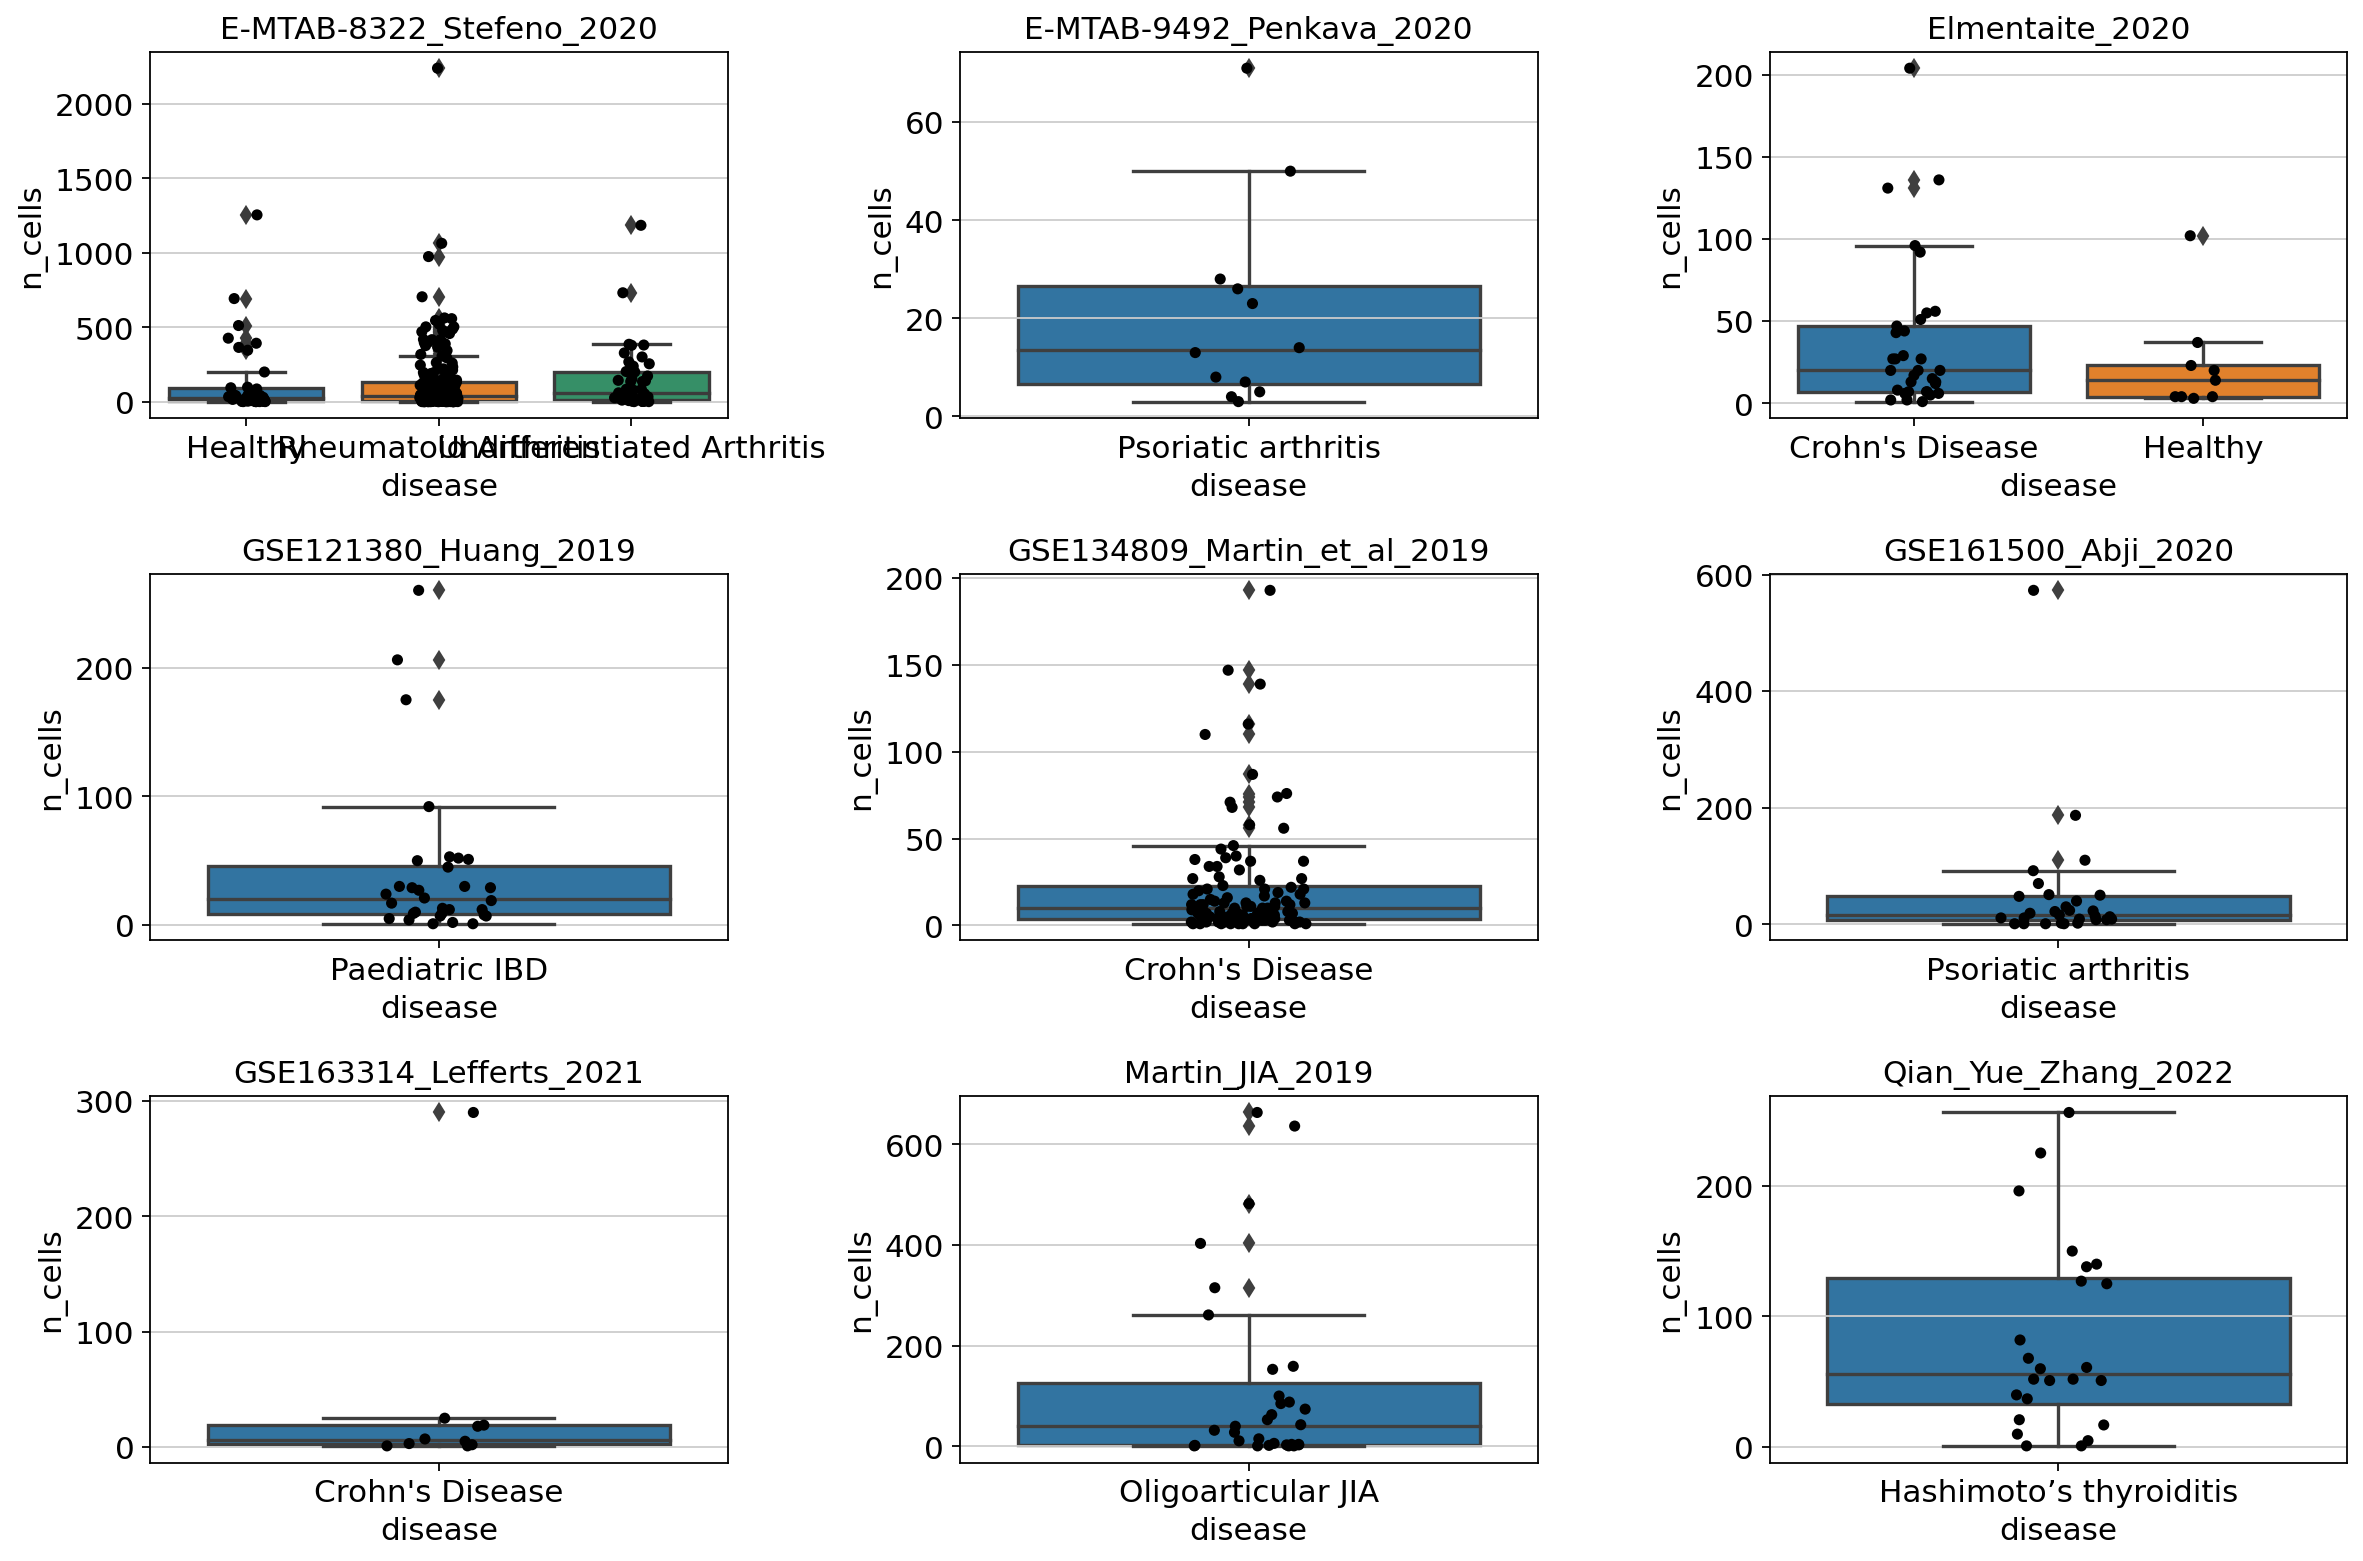

In [25]:
all_datasets = sample_df['dataset_id'].unique()
all_diseases = sample_df['disease'].unique()

with plt.rc_context({'figure.figsize':[15,10]}):
    for i,d in enumerate(all_datasets):
        plt.subplot(3,3,i+1);
        d_df = sample_df[sample_df.dataset_id == d].copy()
        d_df['disease'] = d_df['disease'].astype('str')
        sns.boxplot(
            data = d_df,
            x = 'disease',
            y = 'n_cells'
        );
        sns.stripplot(
            data = d_df,
            x = 'disease',
            y = 'n_cells',
            color = 'black'
        );
        plt.title(d);
    plt.tight_layout()
    plt.show()

Check sample metadata

In [26]:
all_diseases

['Healthy', 'Rheumatoid Arthritis', 'Undifferentiated Arthritis', 'Psoriatic arthritis', 'Crohn's Disease', 'Paediatric IBD', 'Oligoarticular JIA', 'Hashimoto’s thyroiditis']
Categories (8, object): ['Crohn's Disease', 'Hashimoto’s thyroiditis', 'Healthy', 'Oligoarticular JIA', 'Paediatric IBD', 'Psoriatic arthritis', 'Rheumatoid Arthritis', 'Undifferentiated Arthritis']

In [27]:
sample_df['disease'].value_counts()

Rheumatoid Arthritis          196
Crohn's Disease               148
Healthy                        47
Undifferentiated Arthritis     44
Psoriatic arthritis            41
Paediatric IBD                 32
Oligoarticular JIA             31
Hashimoto’s thyroiditis        24
Name: disease, dtype: int64

In [28]:
adata.obs.disease.unique()

['Hashimoto’s thyroiditis', 'Oligoarticular JIA', 'Paediatric IBD', 'Undifferentiated Arthritis', 'Rheumatoid Arthritis', 'Healthy', 'Psoriatic arthritis', 'Crohn's Disease']
Categories (8, object): ['Crohn's Disease', 'Hashimoto’s thyroiditis', 'Healthy', 'Oligoarticular JIA', 'Paediatric IBD', 'Psoriatic arthritis', 'Rheumatoid Arthritis', 'Undifferentiated Arthritis']

In [11]:
## Rename disease (DA code complains because of weird characters in names)
diseases_short = {
    'Psoriatic arthritis':'pso_arthritis',#
    'Rheumatoid Arthritis':'RA',#
    'Undifferentiated Arthritis':'Undif_RA',#
    'Paediatric IBD':'Paed_IBD',#
    #'CD + Spondyloarthritis':"CD_and_spondoarthritis", 
    #'Spondyloarhtritis':"spondoarthritis",
    "Crohn's Disease":"CD", #
    'Healthy':'Healthy',
    #'Uninflamed CD':'Uninfl_CD',#
    'Hashimoto’s thyroiditis':'hashimoto', #
    'Oligoarticular JIA':'Oligo_JIA',#
   #'Osteoarthritis':'OsteoArt'
}
# diseases_short = {v:k for k,v in diseases_short.items()}

In [30]:
adata.obs['disease_short'] = [diseases_short[x] for x in adata.obs['disease']]
# sample_col = 'donor_id'
# condition_col = 'disease'

### Make neighbourhoods

In [31]:
## Make KNN graph for Milo analysis 
k = (sample_df['donor_id'].nunique() * 3) # aim to have 3 cells per donor on avg
sc.pp.neighbors(adata, use_rep='X_scANVI', n_neighbors = k)

In [32]:
milo.make_nhoods(adata, prop=0.05)

In [33]:
len(adata.obs.donor_id.unique())

54

Plot number of cells in neighbourhoods

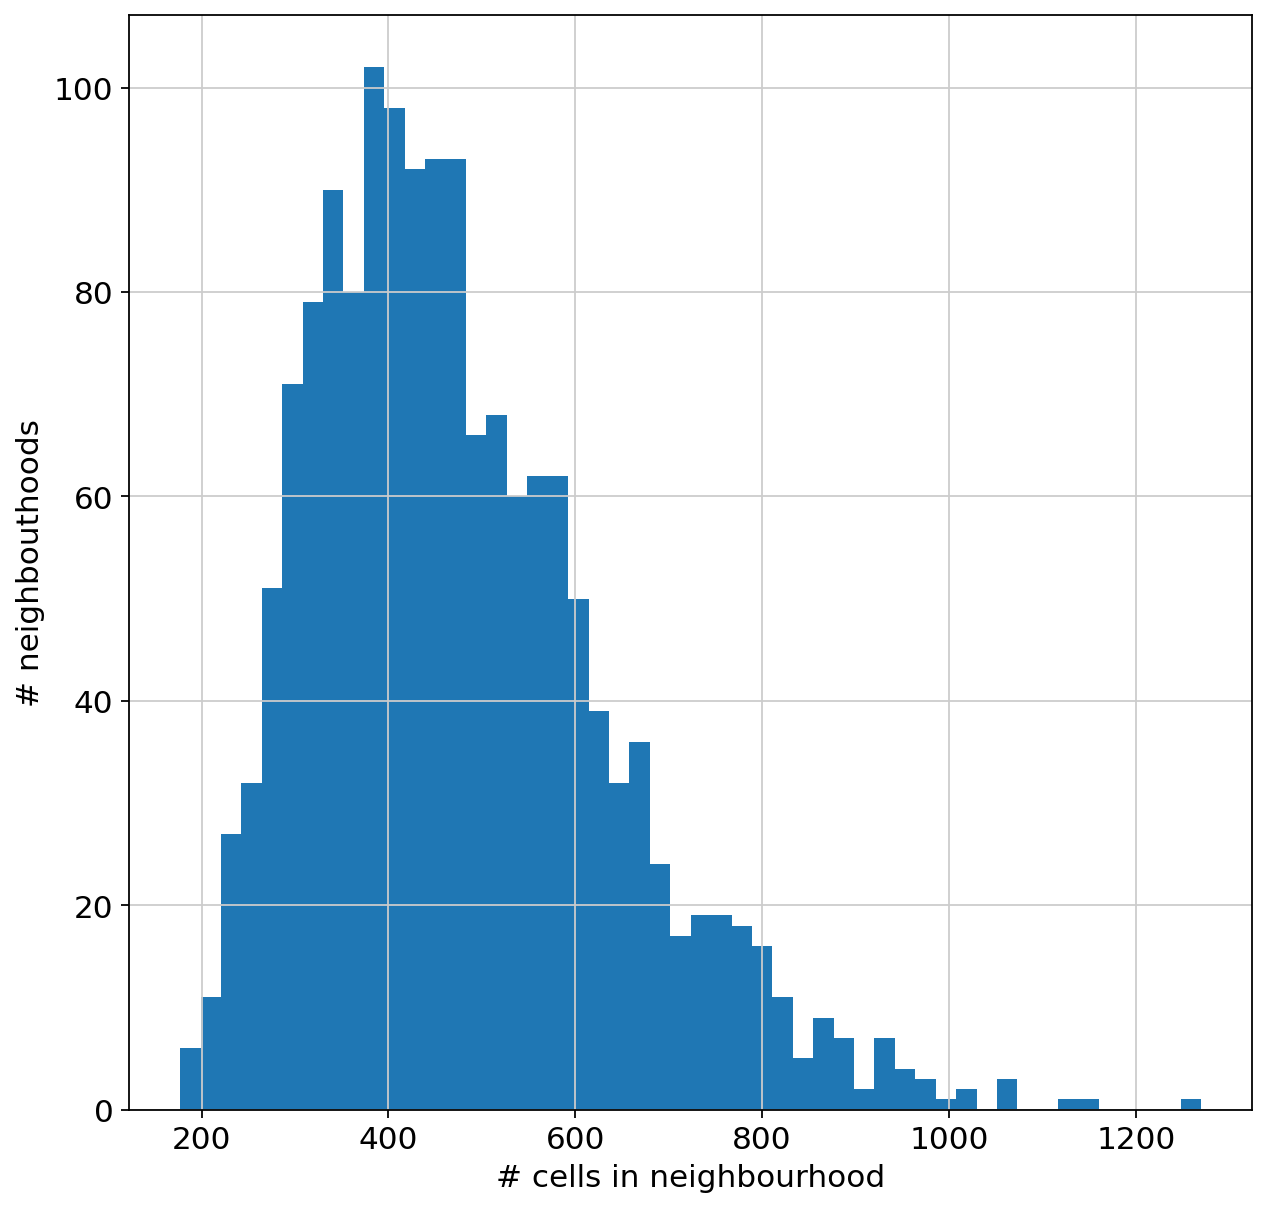

In [34]:
nhood_size = adata.obsm['nhoods'].toarray().sum(0)
plt.hist(nhood_size, bins=50);
plt.xlabel('# cells in neighbourhood');
plt.ylabel('# neighbouthoods');

### Count cells in neighbourhoods

In [35]:
adata.obs['donor_id'] = adata.obs['donor_id'].astype('str') ## Needed for subsetting
milo.count_nhoods(adata, sample_col = 'donor_id')

In [9]:
h5ad_path = '/nfs/team205/bh14/Datasets/Remapped/raw_adata/SCVI_Results/All_Tissue_or_Nonimmune/Subset/Milo/'


#adata.write_h5ad(h5ad_path+'Myeloid_From_Tissue_label_transfert_Subset_annotated_Milo_3K.h5ad')

adata = sc.read_h5ad(h5ad_path+'Myeloid_From_Tissue_label_transfert_Subset_annotated_Milo_3K.h5ad')

In [12]:
sample_cols = ['dataset_id', 'donor_id', 'tissue', 'disease', 'cell_source', 'Cell_type_scANVI']
sample_df = adata.obs[sample_cols].groupby(sample_cols).size().reset_index()
sample_df.columns = sample_cols + ['n_cells']
sample_df = sample_df[sample_df['n_cells'] > 0].copy()

In [13]:
adata

AnnData object with n_obs × n_vars = 48413 × 18033
    obs: 'tissue', 'disease', 'donor_id', 'dataset_id', 'cell_source', 'doublet_scores', 'predicted_doublets', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'total_counts_rb', 'pct_counts_rb', 'QC', 'sex', 'development_stage', 'batch', 'orig.ident', 'n_genes', 'leiden_1_5', 'predicted_labels', 'majority_voting', 'conf_score', '_scvi_batch', 'cell_type', '_scvi_labels', 'barcodes', 'disease_status', 'age', 'developmental_stage', 'barcode', 'sample_id', 'Site', 'Enrichment', 'Location', 'full_clustering', 'log1p_total_counts', 'author_annotation', 'tissue_harmo', 'leiden', 'leiden_man', 'score', 'leiden_R', 'relabeled_cells', 'Cell_type_scANVI', 'Cell_type_scANVI_ori', 'disease_short', 'nhood_ixs_random', 'nhood_ixs_refined', 'nhood_kth_distance', 'over_clustering'
    var: 'mt-0', 'rb-0', 'n_cells_by_counts-0-0-0', 'mean_counts-0-0-0', 'pct_dropout_by_counts-0-0-0', 'total_counts-0-0-0', 'n_cells_by_counts-1-0

In [14]:
import gc
gc.collect()

34

## Run differential abundance test

### 1. Use paired case-controls

For each test restrict to case-control in the same disease

In [15]:
def plot_milo_diagnostics(milo_res):
    '''Function to plot diagnostic plots 
    as in extended vignette https://github.com/Teichlab/scripts/blob/main/conditions/extended_milopy_example.ipynb
    '''
    nhood_adata = adata.uns['nhood_adata'].copy()
    alpha = 0.1 ## significance threshold

    with matplotlib.rc_context({'figure.figsize':[8,8]}):

        ## Check P-value histogram
        plt.subplot(2,2,1);
        plt.hist(milo_res['PValue'], bins=20);
        plt.xlabel('Uncorrected P-value');

        ## Visualize extent of multiple-testing correction
        plt.subplot(2,2,2);
        plt.scatter(milo_res['PValue'], milo_res['SpatialFDR'], s=3);
        plt.xlabel('Uncorrected P-value');
        plt.ylabel('SpatialFDR');

        ## Visualize volcano plot
        plt.subplot(2,2,3);
        plt.scatter(milo_res['logFC'], -np.log10(milo_res['SpatialFDR']), s=3);
        plt.axhline(y=-np.log10(alpha), color='red', linewidth=1, label=f'{int(alpha*100)} % SpatialFDR');
        plt.legend();
        plt.xlabel('log-Fold Change');
        plt.ylabel('- log10(SpatialFDR)');
        plt.tight_layout()

        ## Visualize MA plot
        df = milo_res
        emp_null = df[df['SpatialFDR'] >= alpha]['logFC'].mean()
        df['Sig'] = df['SpatialFDR'] < alpha

        plt.subplot(2,2,4);
        sns.scatterplot(data=df, x="logCPM", y="logFC", hue='Sig')
        plt.axhline(y=0, color='grey', linewidth=1)
        plt.axhline(y=emp_null, color='purple', linewidth=1);
        plt.legend(title=f'< {int(alpha*100)} % SpatialFDR')
        plt.xlabel('Mean log-counts');
        plt.ylabel('log-Fold Change');
        plt.show()
        
def run_DA_autoimmune(adata, sample_df, DA_test_dict):
    '''Wrapper function to run differential abundance testing on autoimmune dataset
    '''
    
    adata.obs['disease_test'] = np.where(adata.obs['disease'].isin(DA_test_dict['disease']), 1, 0)
    
    test_samples = sample_df['donor_id'][sample_df['dataset_id'] == DA_test_dict['dataset_id']].astype('str').values
    
    milo.DA_nhoods(adata, 
                   design="~ donor_id + disease_test",
                   subset_samples=test_samples.tolist()
                  )
    milo_results = adata.uns["nhood_adata"].obs.copy() ## Store results for each disease
    plot_milo_diagnostics(milo_results.dropna())
    return(milo_results)


In [16]:
np.unique(adata.obs.dataset_id)

array(['E-MTAB-8322_Stefeno_2020', 'E-MTAB-9492_Penkava_2020',
       'Elmentaite_2020', 'GSE121380_Huang_2019',
       'GSE134809_Martin_et_al_2019', 'GSE161500_Abji_2020',
       'GSE163314_Lefferts_2021', 'Martin_JIA_2019',
       'Qian_Yue_Zhang_2022'], dtype=object)

In [17]:
adata.obs[["dataset_id", "disease"]].value_counts().sort_index()

dataset_id                   disease                   
E-MTAB-8322_Stefeno_2020     Healthy                        4978
                             Rheumatoid Arthritis          24186
                             Undifferentiated Arthritis     6400
E-MTAB-9492_Penkava_2020     Psoriatic arthritis             252
Elmentaite_2020              Crohn's Disease                1246
                             Healthy                         211
GSE121380_Huang_2019         Paediatric IBD                 1310
GSE134809_Martin_et_al_2019  Crohn's Disease                2315
GSE161500_Abji_2020          Psoriatic arthritis            1446
GSE163314_Lefferts_2021      Crohn's Disease                 371
Martin_JIA_2019              Oligoarticular JIA             3732
Qian_Yue_Zhang_2022          Hashimoto’s thyroiditis        1966
dtype: int64

In [18]:
DA_test_res = {}

In [19]:
#for k in DA_test_dict.keys():
  #  print(k)
 #   DA_test_res[k] = run_DA_autoimmune(adata, sample_df, DA_test_dict=DA_test_dict[k])

Comments:

- Except for the Hong dataset, in all other cases there seems to be too little replicates per condition to detect significant differential abundance in this dataset

### 2. Use all healthy as controls

Tricky because we can't control for the batch effect between datasets (for some conditions we don't have data from all the datasets)

In [20]:
diseases_short

{'Psoriatic arthritis': 'pso_arthritis',
 'Rheumatoid Arthritis': 'RA',
 'Undifferentiated Arthritis': 'Undif_RA',
 'Paediatric IBD': 'Paed_IBD',
 "Crohn's Disease": 'CD',
 'Healthy': 'Healthy',
 'Hashimoto’s thyroiditis': 'hashimoto',
 'Oligoarticular JIA': 'Oligo_JIA'}

In [21]:
milo.DA_nhoods(adata, 
               design="~disease_short",
               model_contrasts='disease_shortCD-disease_shortHealthy'
              )
DA_test_res['all_CD'] = adata.uns['nhood_adata'].obs.copy()

In [22]:
milo.DA_nhoods(adata, 
               design="~disease_short",
               model_contrasts='disease_shortRA-disease_shortHealthy'
              )
DA_test_res['all_RA'] = adata.uns['nhood_adata'].obs.copy()

milo.DA_nhoods(adata, 
               design="~disease_short",
               model_contrasts='disease_shortUndif_RA-disease_shortHealthy'
              )
DA_test_res['all_Undif_RA'] = adata.uns['nhood_adata'].obs.copy()


milo.DA_nhoods(adata, 
               design="~disease_short",
               model_contrasts='disease_shortPaed_IBD-disease_shortHealthy'
              )
DA_test_res['all_Paed_IBD'] = adata.uns['nhood_adata'].obs.copy()

milo.DA_nhoods(adata, 
               design="~disease_short",
               model_contrasts='disease_shortpso_arthritis-disease_shortHealthy'
              )
DA_test_res['all_pso_arthritis'] = adata.uns['nhood_adata'].obs.copy()


milo.DA_nhoods(adata, 
               design="~disease_short",
               model_contrasts='disease_shorthashimoto-disease_shortHealthy'
              )
DA_test_res['all_hashimoto'] = adata.uns['nhood_adata'].obs.copy()


milo.DA_nhoods(adata, 
               design="~disease_short",
               model_contrasts='disease_shortOligo_JIA-disease_shortHealthy'
              )
DA_test_res['all_Oligo_JIA'] = adata.uns['nhood_adata'].obs.copy()

all_CD


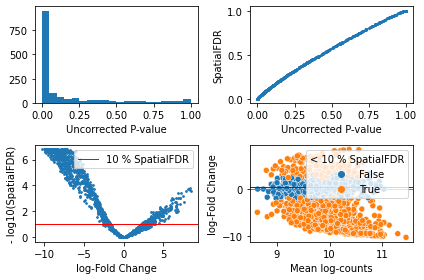

all_RA


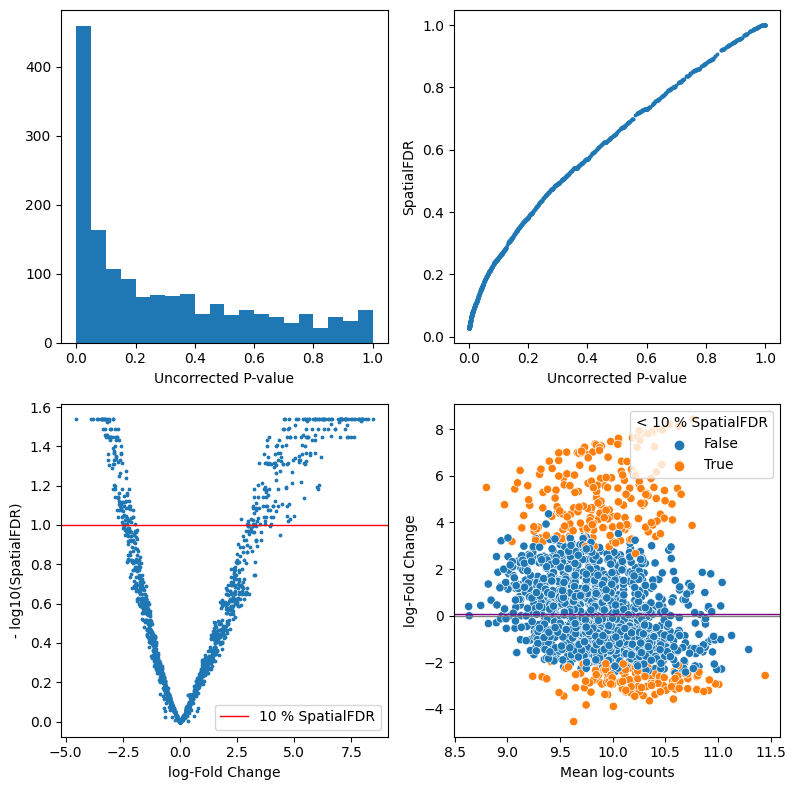

all_Undif_RA


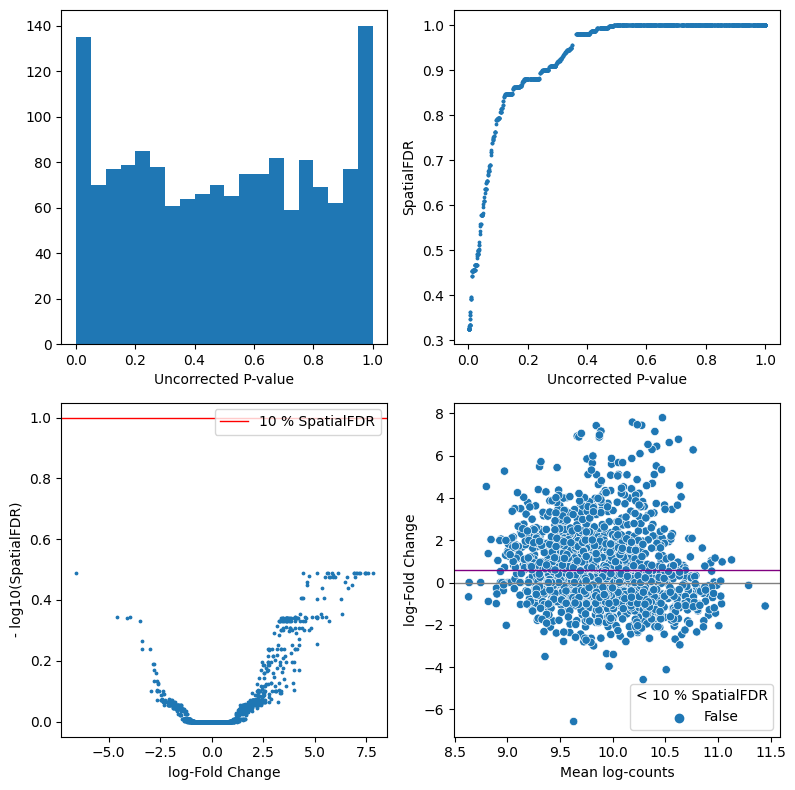

all_Paed_IBD


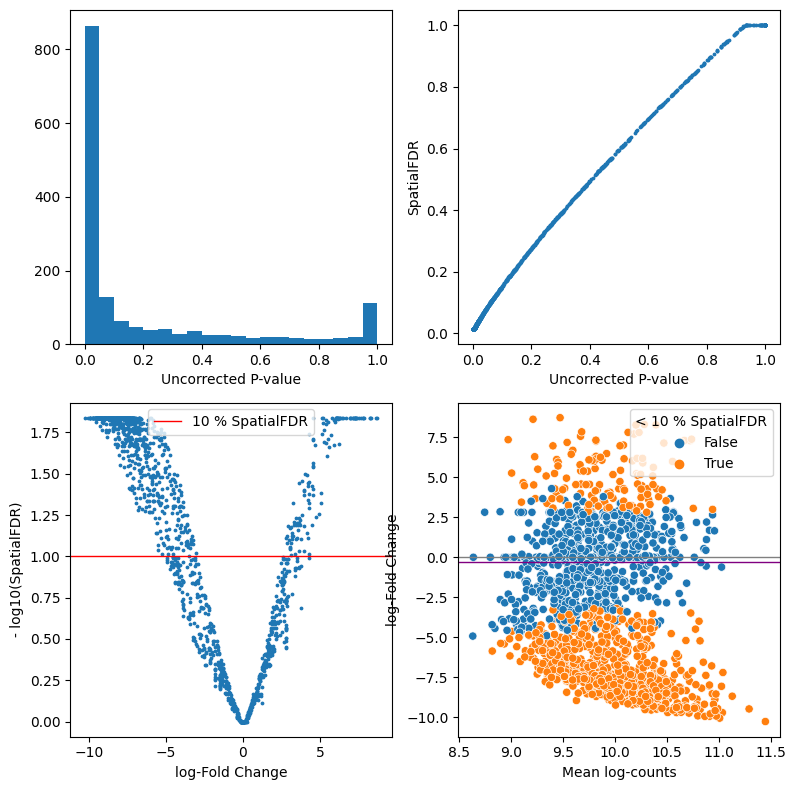

all_pso_arthritis


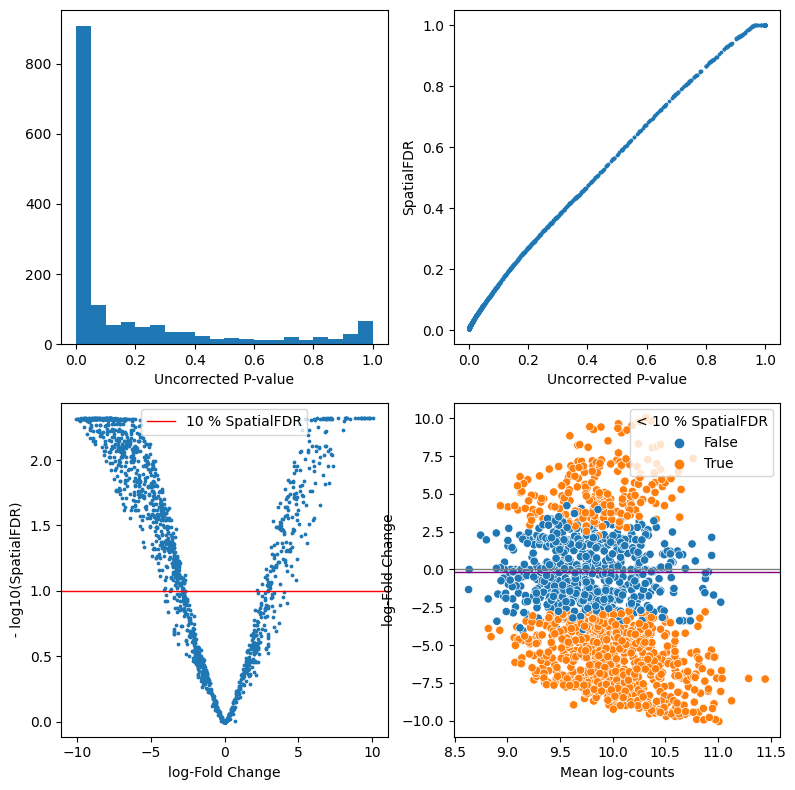

all_hashimoto


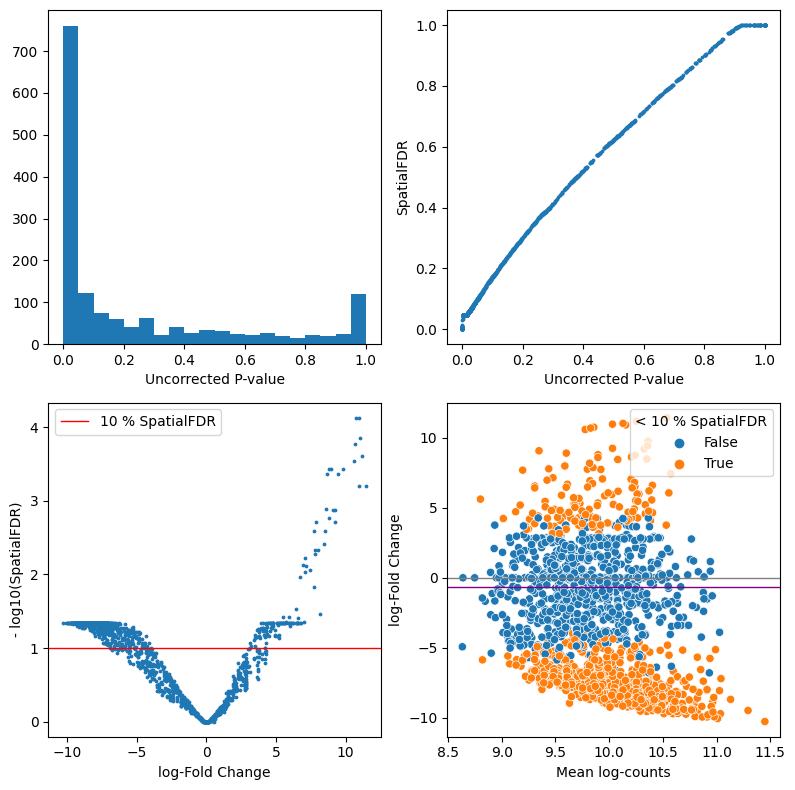

all_Oligo_JIA


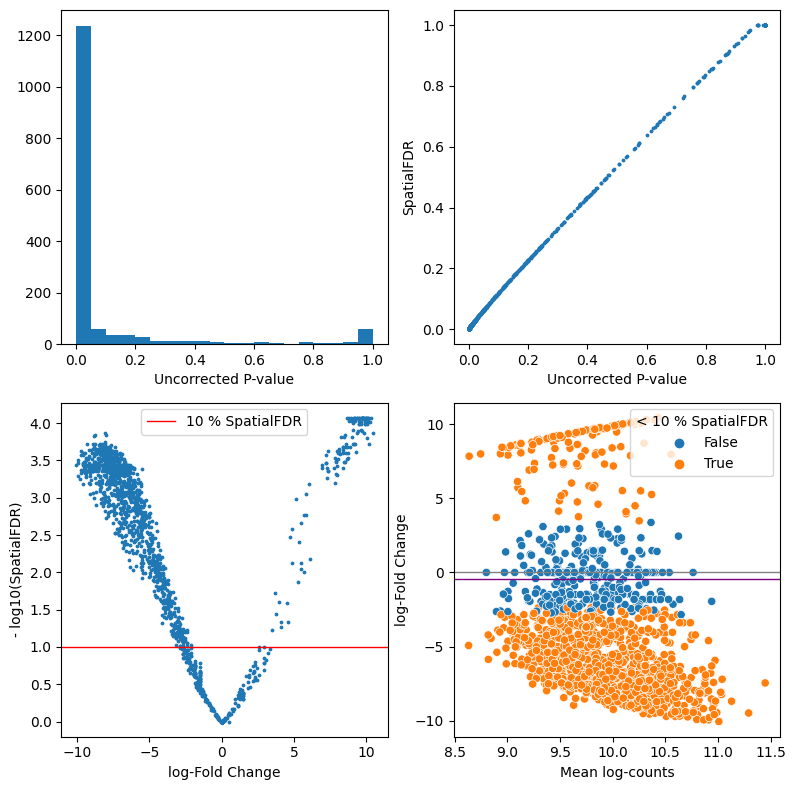

In [23]:
for k in DA_test_res.keys():
    if k.startswith("all_"):
        print(k)
        plot_milo_diagnostics(DA_test_res[k])

Comments:

- In `all_asthma` we see skewed distribution of depleted neighbourhoods (i.e. enriched in Healthy), likely because of the imbalance in number of Healhty and disease donors
- All the others look reasonable in terms of diagnostic statistics, although we might have false positives from batch effects 

## Visualize results by cell type

We select the DA tests where the diagnostic plots look reasonable.

In [24]:
diseases_short

{'Psoriatic arthritis': 'pso_arthritis',
 'Rheumatoid Arthritis': 'RA',
 'Undifferentiated Arthritis': 'Undif_RA',
 'Paediatric IBD': 'Paed_IBD',
 "Crohn's Disease": 'CD',
 'Healthy': 'Healthy',
 'Hashimoto’s thyroiditis': 'hashimoto',
 'Oligoarticular JIA': 'Oligo_JIA'}

The diagnostic plots of 'Undifferentiated Arthritis' does'nt look reasonable  and will be removed from the analysis

In [25]:
keep_tests = ["all_"+val for val in diseases_short.values() if val not in ["Undif_RA", "Healthy"]]

In [26]:
keep_tests

['all_pso_arthritis',
 'all_RA',
 'all_Paed_IBD',
 'all_CD',
 'all_hashimoto',
 'all_Oligo_JIA']

Visualize DA logFC on gene expression UMAP

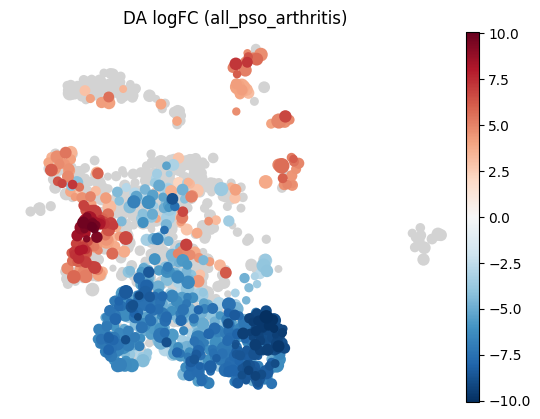

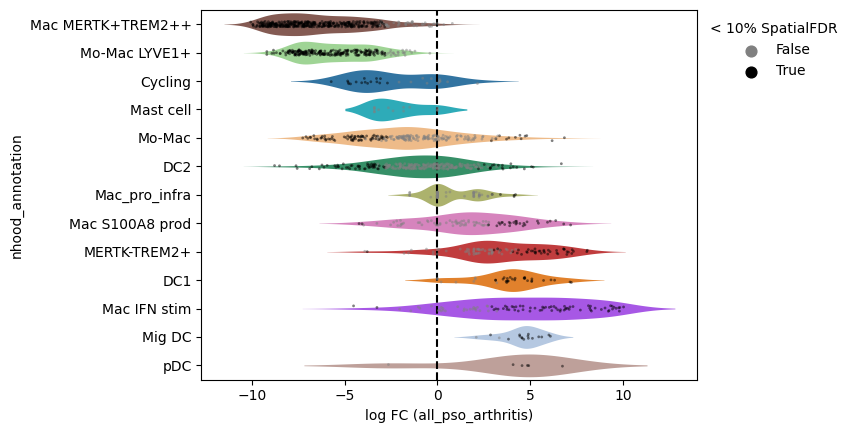

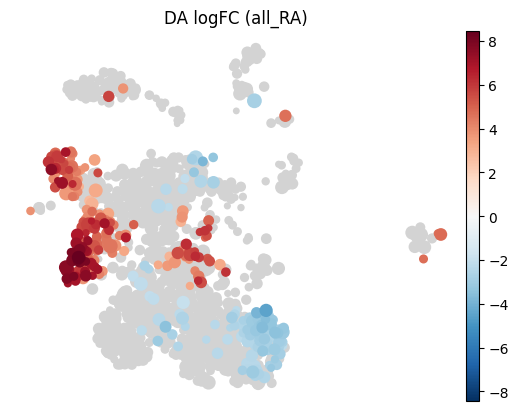

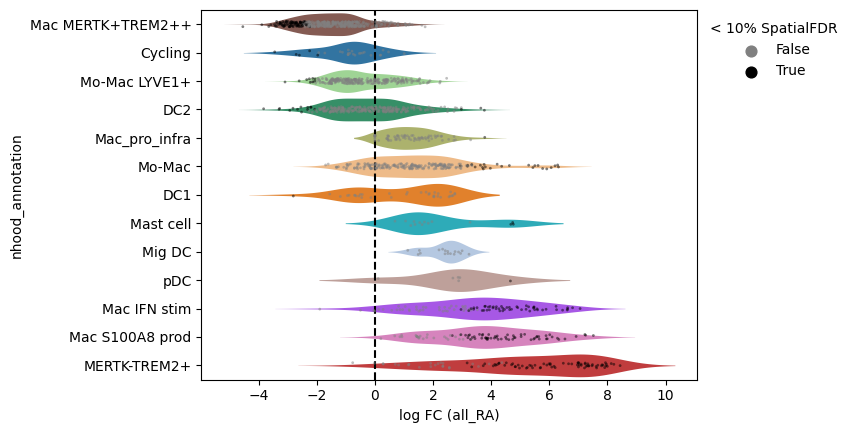

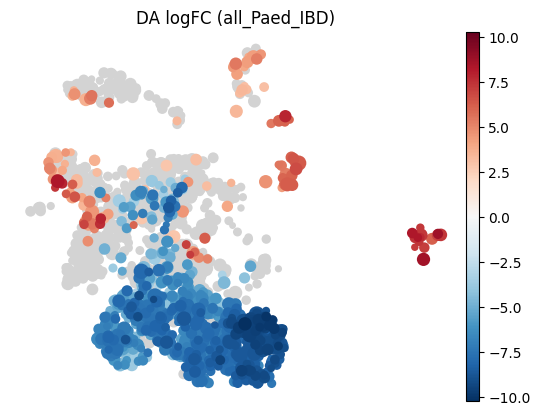

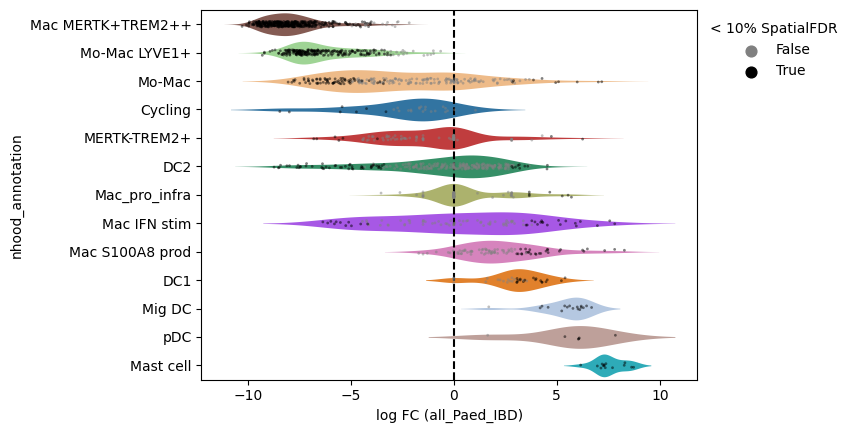

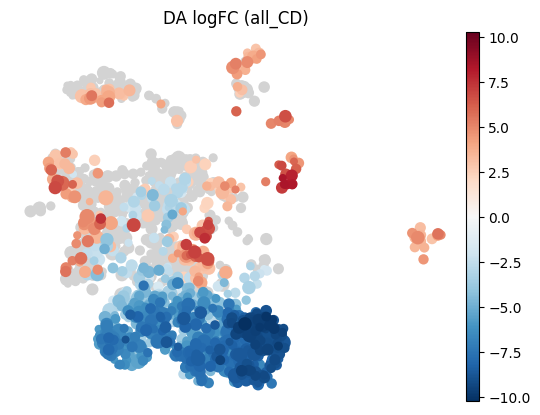

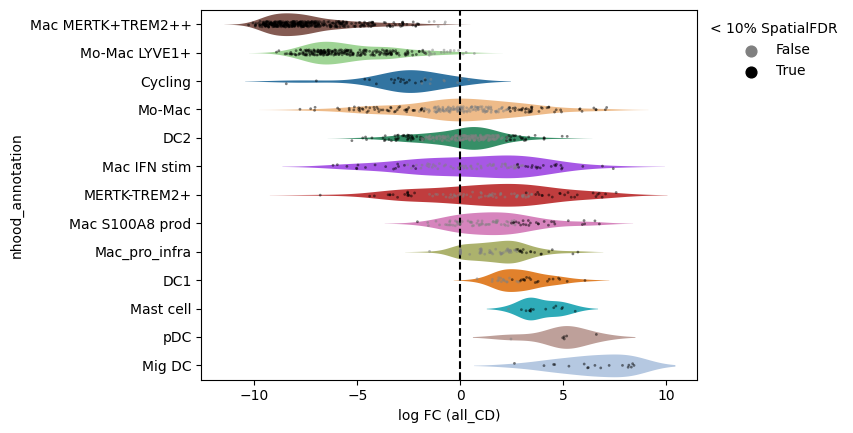

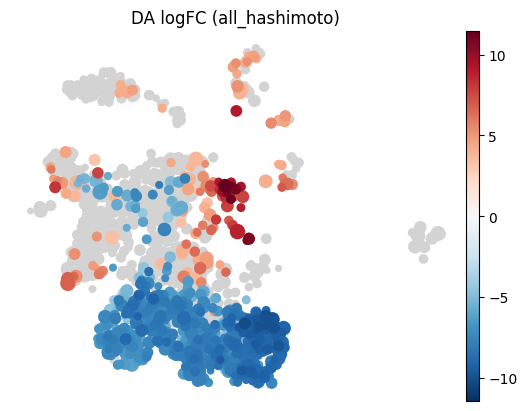

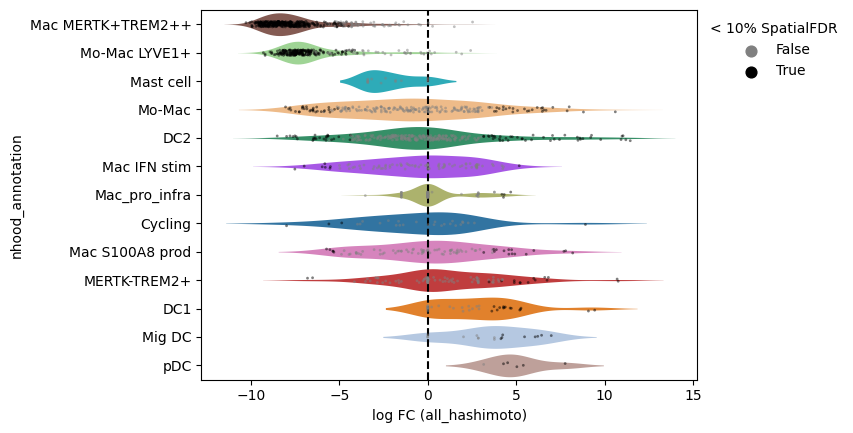

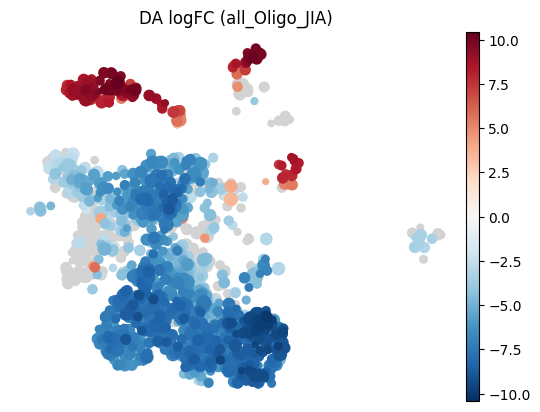

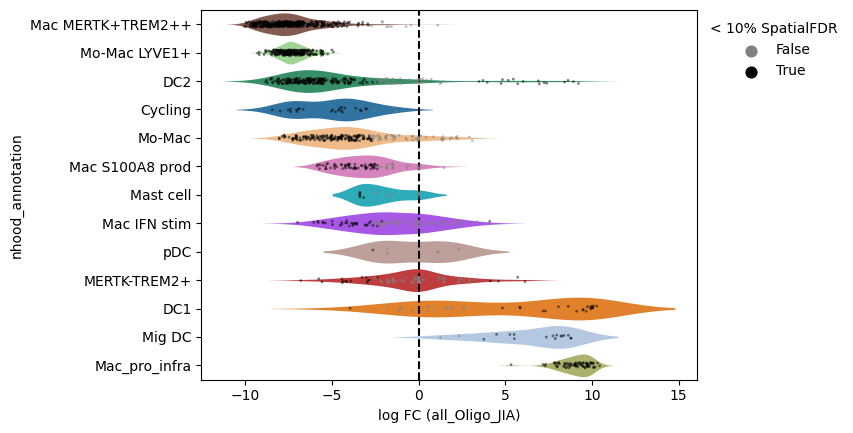

In [27]:
for k in keep_tests:
    
    adata.uns['nhood_adata'].obs = DA_test_res[k].copy()

    ## Plot neighbourhoods on embedding
    milopy.utils.build_nhood_graph(adata)
    milopy.plot.plot_nhood_graph(adata, alpha=0.1, min_size=0.5, title=f'DA logFC ({k})');

    ## Plot by cell type
    milopy.utils.annotate_nhoods(adata, anno_col='Cell_type_scANVI')
    milopy.plot.plot_DA_beeswarm(adata, alpha=0.1);
    plt.xlabel(f'log FC ({k})');
    plt.show()

In [28]:
res_cols = ['logFC', 'SpatialFDR', 'Sig', 'index_cell']

In [29]:
disease_df = []
nhood_annotation = np.array(adata.uns["nhood_adata"].obs['nhood_annotation'])
cell_ind = np.array(adata.uns["nhood_adata"].obs['index_cell'])
for disease in keep_tests:
    
    tab = DA_test_res[disease][res_cols]
    #check if index_cell columns are in the same order
    if any(np.array(adata.uns["nhood_adata"].obs['index_cell']) != tab['index_cell']):
        raise Exception("index_cell don't match...")
    tab["disease"] = np.repeat(disease, tab.shape[0])
    tab["nhood_annotation"] = nhood_annotation
    disease_df.append(tab)

In [36]:
adata.obs#uns["nhood_adata"].obs

,tissue,disease,donor_id,dataset_id,cell_source,doublet_scores,predicted_doublets,n_genes_by_counts,total_counts,total_counts_mt,...,score,leiden_R,relabeled_cells,Cell_type_scANVI,Cell_type_scANVI_ori,disease_short,nhood_ixs_random,nhood_ixs_refined,nhood_kth_distance,over_clustering
AAACCCACACCAGGTC-1_0_0-0,Thyroid,Hashimoto’s thyroiditis,HT28Thyroid,Qian_Yue_Zhang_2022,Thyroid,0.080255,False,2551,8142.0,283.0,...,NaN,7,Mo-Mac,Mo-Mac,Mo-Mac,hashimoto,0,0,0.0,206
AAACCCACATCGGCCA-1_0_0-0,Thyroid,Hashimoto’s thyroiditis,HT28Thyroid,Qian_Yue_Zhang_2022,Thyroid,0.095066,False,3984,16422.0,1325.0,...,NaN,7,Cycling,Cycling,Cycling,hashimoto,0,0,0.0,5
AAACGAACACATGTTG-1_0_0-0,Thyroid,Hashimoto’s thyroiditis,HT28Thyroid,Qian_Yue_Zhang_2022,Thyroid,0.051904,False,4206,28838.0,1614.0,...,NaN,7,Mo-Mac,Mo-Mac,Mo-Mac,hashimoto,0,0,0.0,5
AAACGCTAGATGATTG-1_0_0-0,Thyroid,Hashimoto’s thyroiditis,HT28Thyroid,Qian_Yue_Zhang_2022,Thyroid,0.049717,False,1707,5164.0,344.0,...,NaN,4,Mo-Mac LYVE1+,Mo-Mac LYVE1+,Mo-Mac LYVE1+,hashimoto,0,0,0.0,77
AAACGCTAGCGAGTCA-1_0_0-0,Thyroid,Hashimoto’s thyroiditis,HT28Thyroid,Qian_Yue_Zhang_2022,Thyroid,0.105248,False,3420,17083.0,1752.0,...,NaN,7,Cycling,Cycling,Cycling,hashimoto,0,0,0.0,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TTGGAACGTCCCGACA-0-1-1_1_0_0-1-1,Retrosigmoid Colon,Crohn's Disease,Patient_23_Colon_GSM4977002,GSE163314_Lefferts_2021,Colon,0.080818,False,1998,8208.0,200.0,...,-0.148919,2,DC2,DC2,DC2,CD,0,0,0.0,44
TTTATGCAGCTACCTA-0-1-1_1_0_0-1-1,Retrosigmoid Colon,Crohn's Disease,Patient_23_Colon_GSM4977002,GSE163314_Lefferts_2021,Colon,0.067409,False,784,1788.0,127.0,...,-0.013939,2,DC2,DC2,DC2,CD,0,0,0.0,44
TTTATGCTCACCAGGC-0-1-1_1_0_0-1-1,Retrosigmoid Colon,Crohn's Disease,Patient_23_Colon_GSM4977002,GSE163314_Lefferts_2021,Colon,0.147287,False,2468,9348.0,176.0,...,-0.091915,2,DC2,DC2,DC2,CD,0,0,0.0,57
TTTATGCTCTCACATT-0-1-1_1_0_0-1-1,Retrosigmoid Colon,Crohn's Disease,Patient_23_Colon_GSM4977002,GSE163314_Lefferts_2021,Colon,0.120558,False,1858,5360.0,193.0,...,0.073301,5,Mac S100A8 prod,Mac S100A8 prod,Mac S100A8 prod,CD,0,0,0.0,37


In [30]:
adata.uns["nhood_adata"].obs["Sig"].value_counts()

True     1280
False     290
Name: Sig, dtype: int64

In [31]:
DA_test_res['all_Oligo_JIA']["Sig"].value_counts()

True     1280
False     290
Name: Sig, dtype: int64

In [32]:
#Check number of neighbourhoods
disease_df[0]['nhood_annotation'].value_counts()

Mac MERTK+TREM2++    403
DC2                  261
Mo-Mac LYVE1+        253
Mo-Mac               214
MERTK-TREM2+          93
Mac IFN stim          91
Mac S100A8 prod       84
Mac_pro_infra         72
DC1                   35
Cycling               27
Mig DC                17
Mast cell             14
pDC                    6
Name: nhood_annotation, dtype: int64

In [59]:
compare_disease_df = pd.concat(disease_df)

In [60]:
compare_disease_df.disease.value_counts()

all_pso_arthritis    1570
all_RA               1570
all_Paed_IBD         1570
all_CD               1570
all_hashimoto        1570
all_Oligo_JIA        1570
Name: disease, dtype: int64

## Save


In [61]:
compare_disease_df.to_csv(h5ad_path+"Myeloid_From_Tissue_label_transfer_Milo_3K.csv")

In [6]:
h5ad_path = '/nfs/team205/bh14/Datasets/Remapped/raw_adata/SCVI_Results/All_Tissue_or_Nonimmune/Subset/Milo/'

compare_disease_df = pd.read_csv(h5ad_path+"Myeloid_From_Tissue_label_transfer_Milo_3K.csv")

In [44]:
print(adata.obsm["nhoods"].shape)

(48413, 1570)


In [63]:
h5ad_path+"Myeloid_From_Tissue_label_transfer_Milo_3K.csv"

'/nfs/team205/bh14/Datasets/Remapped/raw_adata/SCVI_Results/All_Tissue_or_Nonimmune/Subset/Milo/Myeloid_From_Tissue_label_transfer_Milo_3K.csv'

In [64]:
adata.obs[['Cell_type_scANVI', 'disease_short', 'nhood_ixs_random', 'nhood_ixs_refined', 'nhood_kth_distance']]

,Cell_type_scANVI,disease_short,nhood_ixs_random,nhood_ixs_refined,nhood_kth_distance
AAACCCACACCAGGTC-1_0_0-0,Mo-Mac,hashimoto,0,0,0.0
AAACCCACATCGGCCA-1_0_0-0,Cycling,hashimoto,0,0,0.0
AAACGAACACATGTTG-1_0_0-0,Mo-Mac,hashimoto,0,0,0.0
AAACGCTAGATGATTG-1_0_0-0,Mo-Mac LYVE1+,hashimoto,0,0,0.0
AAACGCTAGCGAGTCA-1_0_0-0,Cycling,hashimoto,0,0,0.0
...,...,...,...,...,...
TTGGAACGTCCCGACA-0-1-1_1_0_0-1-1,DC2,CD,0,0,0.0
TTTATGCAGCTACCTA-0-1-1_1_0_0-1-1,DC2,CD,0,0,0.0
TTTATGCTCACCAGGC-0-1-1_1_0_0-1-1,DC2,CD,0,0,0.0
TTTATGCTCTCACATT-0-1-1_1_0_0-1-1,Mac S100A8 prod,CD,0,0,0.0


In [65]:
gc.collect()

164649

#### Helper functions

In [45]:
def nhoo_test_data(adata, dir_fc, cell_type, nhoo_fc, n_disease, dis_pref="all_", disease_label = "disease_short"):
    '''
    Prepare adata for DE testing in neighbourhoods. Cells in neighbourhoods with significant enrichment or depletion in at least two 
    diseases are selected and subsequently used to subset the anndata object.
    
    Params:
    -------
    - nhoo_fc: long format dataframe containing milo testing results of all diseases
    - disease_set: list of two or more diseases in which neighbourhoods are simultaneously depleted or enriched 
    - cell_type: str or list of cell types to test in
    - dir_fc str indicating the direction of the fold abundance (ie depleted or enriched)
    - cell_type_label label of column containing manually annotated
    
    
    
    '''
    
    #selected_nhoo_df = nhoo_fc[(nhoo_fc.disease.isin(disease_set)) & (nhoo_fc.nhood_annotation.isin(cell_type))]
    selected_nhoo_df = nhoo_fc[nhoo_fc.nhood_annotation.isin(cell_type)]

    selected_nhoo_df.reset_index(drop=True, inplace=True)
    #check depletion
    cond1 = ((selected_nhoo_df.logFC < 0) & (selected_nhoo_df.Sig))
    #check enrichment
    cond2 = ((selected_nhoo_df.logFC > 0) & (selected_nhoo_df.Sig))
    
    selected_nhoo_df["dir_FC"] = np.where(cond1, "Depleted", 
        np.where(cond2, "Enriched", "Non_sig"))

    #check the indicated direction of FC and save to test_nhoo column
    selected_nhoo_df["test_nhoo"] = np.where(selected_nhoo_df.dir_FC==dir_fc.capitalize(), True, False)
    
    print("")
    print(f"shape of selected_nhoo_df: {selected_nhoo_df.shape}")
    #transfrom in wide data frame and conserve only nhoo names(index_cell)
    selected_nhoo_df = pd.pivot(selected_nhoo_df, index=['index_cell'], columns="disease", values="test_nhoo")

    #Identify cells that match the condictions in all diseases
    selected_nhoo_df["selected_nhoo"] = selected_nhoo_df.values.sum(axis=1)
    
    #selected_nhoo_df.selected_nhoo.replace([0,1], ["divergent", "shared"], inplace=True)
    selected_nhoo_df["selected_nhoo"] = np.where(selected_nhoo_df.selected_nhoo >= n_disease,
                                                "shared", "rest")
    
    selected_nhoo_df["selected_nhoo"] = selected_nhoo_df.selected_nhoo.astype('category')
    
    print("selected_nhoo_df")
    print(selected_nhoo_df.shape)
    #subset adata to maintain only cells of interest
    adata0 = adata[adata.obs.Cell_type_scANVI.isin(cell_type)].copy()
    print("adata0")
    print(adata0.shape)
    gc.collect()
    #Index of selected cells
    ind_cel = np.array(np.where(adata.obs.Cell_type_scANVI.isin(cell_type))).flatten()
    
    #Select cells that appear in at least one nhoo
        #Shared
    shared_nhoo = selected_nhoo_df.selected_nhoo[selected_nhoo_df.selected_nhoo == "shared"].index #shared index
    
    ind_shared = np.where(adata.uns["nhood_adata"].obs.index_cell.isin(shared_nhoo))
    
    ind_shared = np.array(ind_shared).flatten()
    
    cells_in_nhoods_sh = adata.obsm["nhoods"][:,ind_shared].toarray().sum(1) > 0

    cells_in_nhoods_sh_2 = adata0.obs_names[cells_in_nhoods_sh[ind_cel]]
    
    adata0.obs["nhoo_test_condition"] = np.where(adata0.obs_names.isin(cells_in_nhoods_sh_2), "shared", "rest")
                                            
    print(adata0.obs["nhoo_test_condition"].value_counts())

    return adata0

In [67]:
from IPython.display import display

We run DEG analysis using MAST in R as recommended by https://www.sc-best-practices.org/conditions/differential_gene_expression.html#notes-on-edger

In [68]:
def prep_anndata(adata_):
    def fix_dtypes(adata_):
        df = pd.DataFrame(adata_.X.A, index=adata_.obs_names, columns=adata_.var_names)
        df = df.join(adata_.obs)
        return sc.AnnData(df[adata_.var_names], obs=df.drop(columns=adata_.var_names))

    adata_ = fix_dtypes(adata_)
    sc.pp.filter_genes(adata_, min_cells=10)
    return adata_

## Milo horizontal plot

In [69]:
h5ad_path = '/nfs/team205/bh14/Datasets/Remapped/raw_adata/SCVI_Results/All_Tissue_or_Nonimmune/Subset/Milo/'

compare_disease_df = pd.read_csv(h5ad_path+"Myeloid_From_Tissue_label_transfer_Milo_3K.csv", index_col=0)

In [70]:
compare_disease_df

,logFC,SpatialFDR,Sig,index_cell,disease,nhood_annotation
0,1.693952,0.440909,False,AACAAAGTCAAGTAAG-1_0_0-0,all_pso_arthritis,DC2
1,0.479100,0.835479,False,AACAACCCATTGGCAT-1_0_0-0,all_pso_arthritis,DC2
2,-0.710552,0.738550,False,AAGCGTTCAATTAGGA-1_0_0-0,all_pso_arthritis,DC2
3,-3.701736,0.099999,True,ACAAGCTTCGGAGTAG-1_0_0-0,all_pso_arthritis,DC2
4,-2.636810,0.242831,False,ATTTACCTCATTATCC-1_0_0-0,all_pso_arthritis,pDC
...,...,...,...,...,...,...
1565,-6.787558,0.000946,True,GAGGTGATCGGAAACG-0-1-1_1_0_0-1-1,all_Oligo_JIA,DC2
1566,-5.537335,0.003773,True,GATGAGGTCTTTAGTC-0-1-1_1_0_0-1-1,all_Oligo_JIA,DC2
1567,-5.529441,0.001331,True,GTGTTAGCAAGCGTAG-0-1-1_1_0_0-1-1,all_Oligo_JIA,DC2
1568,-6.634352,0.000909,True,TACCTTAAGCGGATCA-0-1-1_1_0_0-1-1,all_Oligo_JIA,DC2


In [73]:
%%R -i compare_disease_df -w 30 -h 12 --units in -r 600
# Source plotting code
source("/home/jovyan/notebooks_bidossessi/Inflammatory/Remapped/autoimmuneSC/Integrated/R/plot_AIID.R")
#head(compare_disease_df)

compare_disease_df$Sig = ifelse(compare_disease_df$Sig == 1, TRUE, FALSE)

#### Prepare data

nhoo_prep = prep_nhoo(nhood_res=compare_disease_df, condition = "disease", Sig = "Sig", thres = 0.1,
                     dis_pref = "all_", index_cell = "index_cell", 
                     nhood_annotation="nhood_annotation", n_shared=0,
                     SpatialFDR = "SpatialFDR", logFC = "logFC")
  

milo_hori_plot = milo_plot_list(nhoo_prep = nhoo_prep, rel_widths = c(1, 0.25),
                                rel_heights = c(3, 2))

milo_hori_plot

## Save prepared data


In [74]:
adata.obs.Cell_type_scANVI.value_counts()

Mac MERTK+TREM2++    10358
DC2                   7439
Mo-Mac LYVE1+         6840
Mo-Mac                5604
Mac IFN stim          3735
MERTK-TREM2+          3234
Mac S100A8 prod       3209
Mac_pro_infra         2275
Cycling               1530
DC1                   1529
Mig DC                1195
Mast cell              915
pDC                    550
Name: Cell_type_scANVI, dtype: int64

In [47]:
#depletion
nhoo_fc=compare_disease_df
n_disease_dict = {
    'Mac MERTK+TREM2++':5,
    'DC2':4,
    'Mo-Mac LYVE1+':5,
    'Mo-Mac':5,
    'MERTK-TREM2+':5,
    'Cycling':5
}

cell_set = [k for k in n_disease_dict.keys()]

dis_pref="all_"
disease_label = "disease_short"
cell_type_label = "Cell_type_scANVI"
dir_fc = "depleted"
compare_with = True
depl_adatas = []

for cel in cell_set:
    print(f"\n processing {cel}...\n")
    
    test_adata_ = nhoo_test_data(adata=adata, dir_fc = dir_fc, cell_type=[cel], dis_pref="all_", 
                                disease_label = "disease_short", nhoo_fc=compare_disease_df,
                                n_disease = n_disease_dict[cel])

    if(len(test_adata_.obs.nhoo_test_condition.unique()) == 1):
        print(f"Check Category of removed data: {test_adata_.obs.nhoo_test_condition.unique()}")
        continue
    
    print("n_disease")
    print(test_adata_.obs.disease_short.value_counts())
    
    gc.collect()
    depl_adatas.append(test_adata_)
    
    del test_adata_

depleted_adata = depl_adatas[0].concatenate(depl_adatas[1:])


 processing Mac MERTK+TREM2++...


shape of selected_nhoo_df: (2418, 9)
selected_nhoo_df
(403, 7)
n_disease
RA               24186
Undif_RA          6400
Healthy           5189
CD                3932
Oligo_JIA         3732
hashimoto         1966
pso_arthritis     1698
Paed_IBD          1310
Name: disease_short, dtype: int64


In [49]:
depleted_adata.obs

,tissue,disease,donor_id,dataset_id,cell_source,doublet_scores,predicted_doublets,n_genes_by_counts,total_counts,total_counts_mt,...,score,leiden_R,relabeled_cells,Cell_type_scANVI,Cell_type_scANVI_ori,disease_short,nhood_ixs_random,nhood_ixs_refined,nhood_kth_distance,over_clustering
AAACCCACACCAGGTC-1_0_0-0-0,Thyroid,Hashimoto’s thyroiditis,HT28Thyroid,Qian_Yue_Zhang_2022,Thyroid,0.080255,False,2551,8142.0,283.0,...,NaN,7,Mo-Mac,Mo-Mac,Mo-Mac,hashimoto,0,0,0.0,206
AAACCCACATCGGCCA-1_0_0-0-0,Thyroid,Hashimoto’s thyroiditis,HT28Thyroid,Qian_Yue_Zhang_2022,Thyroid,0.095066,False,3984,16422.0,1325.0,...,NaN,7,Cycling,Cycling,Cycling,hashimoto,0,0,0.0,5
AAACGAACACATGTTG-1_0_0-0-0,Thyroid,Hashimoto’s thyroiditis,HT28Thyroid,Qian_Yue_Zhang_2022,Thyroid,0.051904,False,4206,28838.0,1614.0,...,NaN,7,Mo-Mac,Mo-Mac,Mo-Mac,hashimoto,0,0,0.0,5
AAACGCTAGATGATTG-1_0_0-0-0,Thyroid,Hashimoto’s thyroiditis,HT28Thyroid,Qian_Yue_Zhang_2022,Thyroid,0.049717,False,1707,5164.0,344.0,...,NaN,4,Mo-Mac LYVE1+,Mo-Mac LYVE1+,Mo-Mac LYVE1+,hashimoto,0,0,0.0,77
AAACGCTAGCGAGTCA-1_0_0-0-0,Thyroid,Hashimoto’s thyroiditis,HT28Thyroid,Qian_Yue_Zhang_2022,Thyroid,0.105248,False,3420,17083.0,1752.0,...,NaN,7,Cycling,Cycling,Cycling,hashimoto,0,0,0.0,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TTGGAACGTCCCGACA-0-1-1_1_0_0-1-1-0,Retrosigmoid Colon,Crohn's Disease,Patient_23_Colon_GSM4977002,GSE163314_Lefferts_2021,Colon,0.080818,False,1998,8208.0,200.0,...,-0.148919,2,DC2,DC2,DC2,CD,0,0,0.0,44
TTTATGCAGCTACCTA-0-1-1_1_0_0-1-1-0,Retrosigmoid Colon,Crohn's Disease,Patient_23_Colon_GSM4977002,GSE163314_Lefferts_2021,Colon,0.067409,False,784,1788.0,127.0,...,-0.013939,2,DC2,DC2,DC2,CD,0,0,0.0,44
TTTATGCTCACCAGGC-0-1-1_1_0_0-1-1-0,Retrosigmoid Colon,Crohn's Disease,Patient_23_Colon_GSM4977002,GSE163314_Lefferts_2021,Colon,0.147287,False,2468,9348.0,176.0,...,-0.091915,2,DC2,DC2,DC2,CD,0,0,0.0,57
TTTATGCTCTCACATT-0-1-1_1_0_0-1-1-0,Retrosigmoid Colon,Crohn's Disease,Patient_23_Colon_GSM4977002,GSE163314_Lefferts_2021,Colon,0.120558,False,1858,5360.0,193.0,...,0.073301,5,Mac S100A8 prod,Mac S100A8 prod,Mac S100A8 prod,CD,0,0,0.0,37


In [77]:
#depleted_adata = prep_anndata(adata_=depleted_adata)

In [78]:
depleted_adata.write_h5ad(h5ad_path+"depleted_nhoo/Tissue_Myeloid_depleted_Milo_adata.h5ad")

In [79]:
del depleted_adata

In [80]:
del depl_adatas

#### Enriched

In [82]:
%%R -i compare_disease_df -w 30 -h 12 --units in -r 600
# Source plotting code
source("/home/jovyan/notebooks_bidossessi/Inflammatory/Remapped/autoimmuneSC/Integrated/R/plot_AIID.R")
#head(compare_disease_df)

compare_disease_df$Sig = ifelse(compare_disease_df$Sig == 1, TRUE, FALSE)

#### Prepare data

nhoo_prep = prep_nhoo(nhood_res=compare_disease_df, condition = "disease", Sig = "Sig", thres = 0.1,
                     dis_pref = "all_", index_cell = "index_cell", 
                     nhood_annotation="nhood_annotation", n_shared=0,
                     SpatialFDR = "SpatialFDR", logFC = "logFC")
  

milo_hori_plot = milo_plot_list(nhoo_prep = nhoo_prep, rel_widths = c(1, 0.25),
                                rel_heights = c(3, 2))

milo_hori_plot

In [83]:
#Enrichment
gc.collect()

nhoo_fc=compare_disease_df
n_disease_dict = {
    'Mo-Mac':4,#
    'Mac IFN stim':4,#
    'Mac_pro_infra':4,#
    'Mac S100A8 prod':4,#
    'DC1':5,#
    'Mig DC': 5,#
    'pDC':4,
    'MERTK-TREM2+':4#
}

cell_set = [k for k in n_disease_dict.keys()]

dis_pref="all_"
disease_label = "disease_short"
cell_type_label = "Cell_type_scANVI"
dir_fc = "enriched"
compare_with = True
enriched_adatas = []

for cel in cell_set:

    cell_type = [cel]
    print(f"\n processing {cel}...\n")

    test_adata = nhoo_test_data(adata=adata, dir_fc = dir_fc, cell_type=cell_type, 
                                dis_pref="all_", disease_label = "disease_short", 
                                nhoo_fc=compare_disease_df, n_disease=n_disease_dict[cel])

    if(len(test_adata.obs.nhoo_test_condition.unique()) == 1):
        print(f"Check Category of removed data: {test_adata.obs.nhoo_test_condition.unique()}")
        continue
    
    print("n_disease")
    print(test_adata.obs.disease_short.value_counts())
    
    enriched_adatas.append(test_adata)

enriched_adata = enriched_adatas[0].concatenate(enriched_adatas[1:])


 processing Mo-Mac...


shape of selected_nhoo_df: (1284, 8)
selected_nhoo_df
(214, 7)
adata0
(5604, 18033)
rest      4456
shared    1148
Name: nhoo_test_condition, dtype: int64
n_disease
RA               3977
CD                529
Undif_RA          505
hashimoto         323
Healthy           200
Paed_IBD           38
pso_arthritis      25
Oligo_JIA           7
Name: disease_short, dtype: int64

 processing Mac IFN stim...


shape of selected_nhoo_df: (546, 8)
selected_nhoo_df
(91, 7)
adata0
(3735, 18033)
rest      2272
shared    1463
Name: nhoo_test_condition, dtype: int64
n_disease
RA               2184
pso_arthritis     855
Undif_RA          238
CD                182
hashimoto         113
Paed_IBD           75
Healthy            62
Oligo_JIA          26
Name: disease_short, dtype: int64

 processing Mac_pro_infra...


shape of selected_nhoo_df: (432, 8)
selected_nhoo_df
(72, 7)
adata0
(2275, 18033)
rest      1925
shared     350
Name: nhoo_test_condition, dtype: int64
n_disease
Olig

In [84]:
#enriched_adata = prep_anndata(adata_=enriched_adata)

In [85]:
enriched_adata.write_h5ad(h5ad_path+"enriched_nhoo/Tissue_Myeloid_enriched_Milo_adata.h5ad")

In [86]:
del enriched_adata

In [87]:
del test_adata
del enriched_adatas
gc.collect()

5253

In [35]:
#h5ad_path = '/nfs/team205/bh14/Datasets/Remapped/raw_adata/SCVI_Results/All_Tissue_or_Nonimmune/Subset/Milo/'

#adata = sc.read_h5ad(h5ad_path+'Myeloid_From_Tissue_label_transfert_With_MiloData_3K.h5ad')

In [1]:
import scanpy as sc